In [2]:
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np


import geopandas as gpd
import json

In [3]:
df = gpd.read_file('roads_all_2019.geojson')


In [4]:
df.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 4383 entries, 0 to 4382
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   OBJECTID    4383 non-null   int64   
 1   ACCESS      4383 non-null   object  
 2   CODE        1142 non-null   object  
 3   NAME        3877 non-null   object  
 4   BOUNDARY    1373 non-null   object  
 5   CLASS_DEFI  4382 non-null   object  
 6   SURFACE     4381 non-null   object  
 7   LENGTH_KM   4383 non-null   float64 
 8   CLASS       4383 non-null   object  
 9   Alias       13 non-null     object  
 10  Category    4380 non-null   object  
 11  Type        3103 non-null   object  
 12  Speed       4383 non-null   int64   
 13  geometry    4383 non-null   geometry
dtypes: float64(1), geometry(1), int64(2), object(10)
memory usage: 479.5+ KB


In [6]:
df.ACCESS.unique()

array(['Staff', 'Private', 'Public'], dtype=object)

In [9]:
len(df.OBJECTID.unique())

1143

In [10]:
len(df)

4383

In [21]:
df.SURFACE.unique()

array(['Graded', 'Two Track', 'Disused', 'Gravel', 'Tar', 'Rehab', None],
      dtype=object)

In [22]:
gp = df.groupby(['SURFACE']).size().reset_index(name='count')
gp

,SURFACE,count
0,Disused,493
1,Graded,1763
2,Gravel,1042
3,Rehab,23
4,Tar,713
5,Two Track,347


In [27]:
gp = df.groupby(['CLASS_DEFI']).size().reset_index(name='count')
gp

,CLASS_DEFI,count
0,4x4 Eco Trail,58
1,Access Road,133
2,Bush Lodge Roads,5
3,Bushveld Camp Roads,51
4,Camp Site Roads,2
5,Concession Road,3
6,Disused,489
7,Firebreak Road,332
8,Jeep / 4x4 Road,99
9,Loop Road,95


In [28]:
gp = df.groupby(['CLASS']).size().reset_index(name='count')
gp

,CLASS,count
0,Concession Road,512
1,Disused,501
2,Firebreak Road,283
3,Jeep / 4x4 Road,57
4,Management Road,1479
5,Private Tourist Gravel Road,55
6,Private Tourist Tar Road,1
7,Rehab,23
8,Rest Camp Roads,310
9,Tourist 4x4 Road,10


<AxesSubplot:>

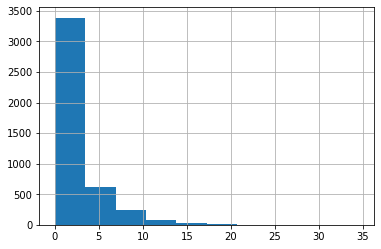

In [24]:
df.LENGTH_KM.hist()

In [25]:
df.CLASS.unique()

array(['Management Road', 'Disused', 'Jeep / 4x4 Road',
       'Tourist Gravel Road', 'Tourist 4x4 Road', 'Concession Road',
       'Rehab', 'Private Tourist Gravel Road', 'Tourist Tar Road',
       'Rest Camp Roads', 'Firebreak Road', 'Private Tourist Tar Road'],
      dtype=object)

In [26]:
df.CLASS_DEFI.unique()

array(['Management Road', 'Jeep / 4x4 Road', 'Disused', '4x4 Eco Trail',
       'Other', 'Tourist Gravel Road', 'Firebreak Road',
       'Tourist 4x4 Road', 'Staff Village Road', 'Access Road',
       'Private Tourist Gravel Road', 'Rehab Firebreak Road', 'Loop Road',
       'Tourist Tar Road', 'Rest Camp Roads', 'Concession Road',
       'Patrol Road', 'Private Tourist Tar Road', 'Bushveld Camp Roads',
       'Bush Lodge Roads', 'Satellite Camp Roads', 'Camp Site Roads',
       'New Roads', 'Patrol Camp Road', 'Trails Camp Road', None],
      dtype=object)

In [29]:
df.Alias.unique()

array([None, 'Sabie Poort F/B', 'Mpanamana Road', 'Mnyeleni F/B',
       'Matjulu F/B', 'Mavukane F/B', 'Possible private tourist gravel'],
      dtype=object)

In [30]:
gp = df.groupby(['Alias']).size().reset_index(name='count')
gp

,Alias,count
0,Matjulu F/B,1
1,Mavukane F/B,2
2,Mnyeleni F/B,1
3,Mpanamana Road,3
4,Possible private tourist gravel,1
5,Sabie Poort F/B,5


In [31]:
df.Category.unique()

array(['Management', 'Tourist', 'Concession Road', 'Rehab', 'Transit',
       None], dtype=object)

In [32]:
gp = df.groupby(['Category']).size().reset_index(name='count')
gp

,Category,count
0,Concession Road,512
1,Management,2319
2,Rehab,23
3,Tourist,1093
4,Transit,433


In [33]:
df.Category.value_counts(dropna=False)

Management         2319
Tourist            1093
Concession Road     512
Transit             433
Rehab                23
NaN                   3
Name: Category, dtype: int64

In [34]:
df.Type.value_counts(dropna=False)

D1     1364
NaN    1280
A1      433
B2      420
E1      382
B1      306
A3      147
C1       44
B         3
A         3
A2        1
Name: Type, dtype: int64

In [35]:
df.Speed.value_counts(dropna=False)

40    3066
0      478
50     438
30     401
Name: Speed, dtype: int64